# Fund Prediction

Notebook ini membandingkan tiga metode untuk memprediksi total volume pengajuan diterima pada periode berikutnya:

1. Linear Regression
2. Moving Average
3. Exponential Smoothing

Model terbaik dipilih berdasarkan nilai RMSE terendah pada data pengujian. Setelah volume diprediksi, kebutuhan dana dihitung menggunakan harga acuan yang dimasukkan stakeholder:

$$\text{Predicted Fund} = \text{Predicted Volume} \times \text{Stakeholder Reference Price}$$

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use("ggplot")
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

## 1. Memuat dan menyiapkan data

Model hanya menggunakan histori `total_accepted_application_volume`. `reference_price` tidak digunakan untuk melatih model karena nilainya ditentukan stakeholder saat prediksi dilakukan.

In [2]:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_path = project_root / "data" / "waste_oil_dummy.csv"

df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["period"], format="%Y-%m")
df = df.sort_values("date").reset_index(drop=True)
df["time_index"] = np.arange(1, len(df) + 1)

df[["period", "total_accepted_application_volume", "reference_price"]].head()

,period,total_accepted_application_volume,reference_price
0,2023-01,1200,13000
1,2023-02,1280,12250
2,2023-03,1350,12500
3,2023-04,1420,13000
4,2023-05,1390,14250


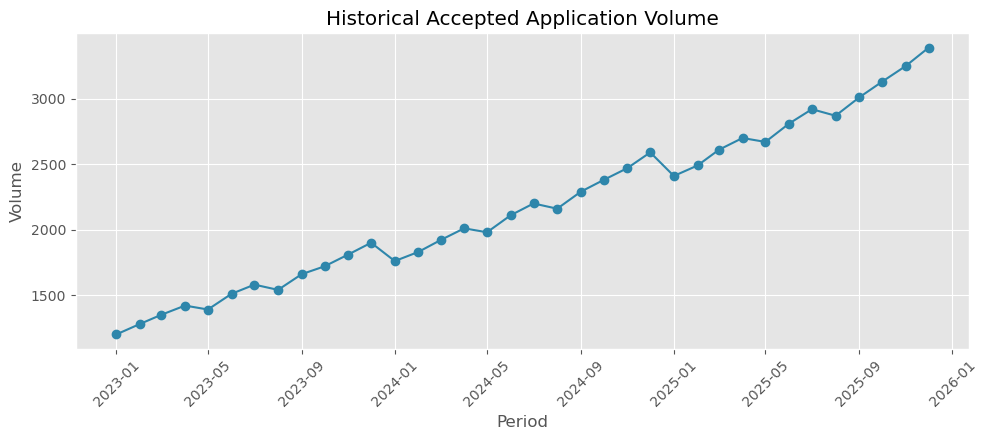

In [3]:
target_column = "total_accepted_application_volume"

if df[target_column].isna().any():
    raise ValueError("The target column contains missing values.")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(df["date"], df[target_column], marker="o", color="#2E86AB")
ax.set(title="Historical Accepted Application Volume", xlabel="Period", ylabel="Volume")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 2. Membagi data berdasarkan waktu

Enam periode terakhir digunakan sebagai test set. Data tidak diacak karena model tidak boleh belajar dari informasi masa depan.

In [4]:
test_size = 6
train_df = df.iloc[:-test_size].copy()
test_df = df.iloc[-test_size:].copy()

print(f"Training period: {train_df['period'].iloc[0]} to {train_df['period'].iloc[-1]}")
print(f"Testing period: {test_df['period'].iloc[0]} to {test_df['period'].iloc[-1]}")
print(f"Training records: {len(train_df)}")
print(f"Testing records: {len(test_df)}")

Training period: 2023-01 to 2025-06
Testing period: 2025-07 to 2025-12
Training records: 30
Testing records: 6


## 3. Fungsi evaluasi

- MAE menunjukkan rata-rata selisih absolut prediksi.
- RMSE memberi penalti lebih besar pada kesalahan yang besar dan menjadi dasar pemilihan model.
- MAPE menunjukkan rata-rata kesalahan dalam persentase.

In [5]:
def calculate_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape}


def simple_exponential_smoothing(values, alpha):
    level = float(values[0])
    for value in values[1:]:
        level = alpha * float(value) + (1 - alpha) * level
    return level

## 4. Eksperimen model

Moving Average menggunakan tiga observasi terakhir. Exponential Smoothing menggunakan `alpha = 0.5`, sehingga data terbaru mendapat bobot lebih besar. Kedua metode dievaluasi secara walk-forward: setelah satu periode diuji, nilai aktual periode tersebut ditambahkan ke histori sebelum memprediksi periode berikutnya.

In [6]:
# Linear Regression
linear_model = LinearRegression()
linear_model.fit(train_df[["time_index"]], train_df[target_column])
linear_predictions = linear_model.predict(test_df[["time_index"]])

# Moving Average
moving_average_window = 3
moving_history = train_df[target_column].astype(float).tolist()
moving_average_predictions = []

for actual_value in test_df[target_column]:
    prediction = np.mean(moving_history[-moving_average_window:])
    moving_average_predictions.append(prediction)
    moving_history.append(float(actual_value))

# Exponential Smoothing
smoothing_alpha = 0.5
smoothing_level = simple_exponential_smoothing(
    train_df[target_column].to_numpy(), smoothing_alpha
)
exponential_predictions = []

for actual_value in test_df[target_column]:
    exponential_predictions.append(smoothing_level)
    smoothing_level = (
        smoothing_alpha * float(actual_value)
        + (1 - smoothing_alpha) * smoothing_level
    )

## 5. Membandingkan performa

In [7]:
actual_values = test_df[target_column].to_numpy()
model_predictions = {
    "Linear Regression": linear_predictions,
    "Moving Average": moving_average_predictions,
    "Exponential Smoothing": exponential_predictions,
}

evaluation_rows = []
for model_name, predictions in model_predictions.items():
    metrics = calculate_metrics(actual_values, predictions)
    evaluation_rows.append({"Model": model_name, **metrics})

evaluation_df = pd.DataFrame(evaluation_rows).sort_values("RMSE").reset_index(drop=True)
evaluation_df

,Model,MAE,RMSE,MAPE
0,Linear Regression,143.62,173.47,4.48
1,Exponential Smoothing,179.12,190.57,5.71
2,Moving Average,185.00,195.77,5.89


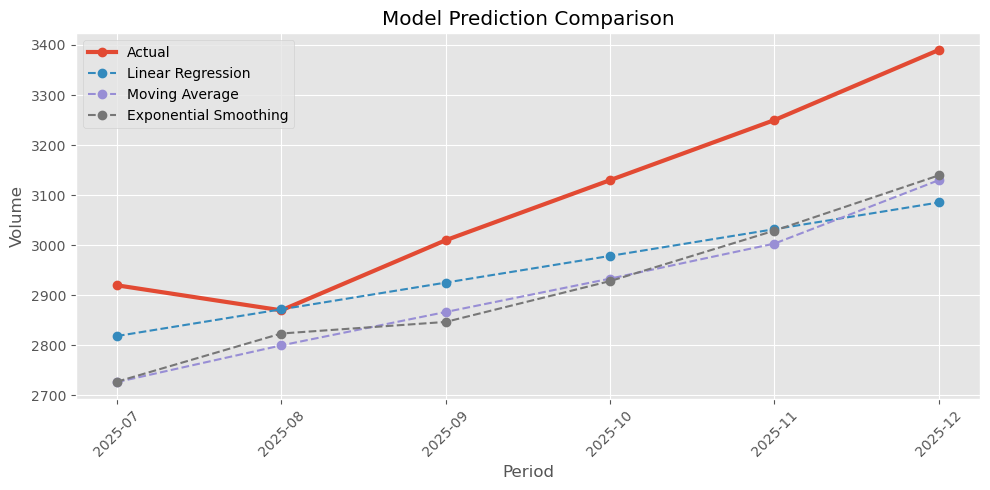

,period,total_accepted_application_volume,Linear Regression,Moving Average,Exponential Smoothing
30,2025-07,2920,"2,818.67","2,726.67","2,727.45"
31,2025-08,2870,"2,872.02","2,800.00","2,823.72"
32,2025-09,3010,"2,925.38","2,866.67","2,846.86"
33,2025-10,3130,"2,978.73","2,933.33","2,928.43"
34,2025-11,3250,"3,032.09","3,003.33","3,029.22"
35,2025-12,3390,"3,085.44","3,130.00","3,139.61"


In [8]:
comparison_df = test_df[["period", target_column]].copy()
for model_name, predictions in model_predictions.items():
    comparison_df[model_name] = predictions

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(comparison_df["period"], comparison_df[target_column], marker="o", linewidth=3, label="Actual")

for model_name in model_predictions:
    ax.plot(comparison_df["period"], comparison_df[model_name], marker="o", linestyle="--", label=model_name)

ax.set(title="Model Prediction Comparison", xlabel="Period", ylabel="Volume")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

comparison_df

**Hasil eksperimen pada data dummy saat ini:** Linear Regression menjadi metode terbaik dengan RMSE sekitar **173,47**, diikuti Exponential Smoothing sekitar **190,57** dan Moving Average sekitar **195,77**. Linear Regression unggul karena histori volume memiliki pola tren naik yang cukup kuat. Hasil ini berlaku untuk dataset saat ini; notebook tetap menghitung ulang pemenang secara otomatis jika data berubah.

## 6. Memilih dan melatih ulang model terbaik

Model dengan RMSE terendah dipilih secara otomatis. Setelah dipilih, model dilatih kembali menggunakan seluruh data agar prediksi periode berikutnya memanfaatkan semua histori yang tersedia.

In [9]:
best_model_name = evaluation_df.loc[0, "Model"]
next_time_index = int(df["time_index"].iloc[-1] + 1)
model_package = {"model_name": best_model_name}

if best_model_name == "Linear Regression":
    final_model = LinearRegression()
    final_model.fit(df[["time_index"]], df[target_column])
    next_volume = final_model.predict(pd.DataFrame({"time_index": [next_time_index]}))[0]
    model_package.update({"model": final_model})

elif best_model_name == "Moving Average":
    recent_values = df[target_column].tail(moving_average_window).astype(float).tolist()
    next_volume = np.mean(recent_values)
    model_package.update({
        "window": moving_average_window,
        "recent_values": recent_values,
    })

else:
    final_level = simple_exponential_smoothing(
        df[target_column].to_numpy(), smoothing_alpha
    )
    next_volume = final_level
    model_package.update({
        "alpha": smoothing_alpha,
        "level": final_level,
    })

predicted_volume = max(0, int(round(next_volume)))

print(f"Best model: {best_model_name}")
print(f"Predicted volume: {predicted_volume:,}")

Best model: Linear Regression
Predicted volume: 3,228


## 7. Menghitung prediksi dana

Harga acuan berikut dapat diganti oleh stakeholder. Contoh ini menggunakan Rp13.000.

In [10]:
stakeholder_reference_price = 13_000
predicted_fund = predicted_volume * stakeholder_reference_price

prediction_output = {
    "predicted_volume": predicted_volume,
    "predicted_fund": predicted_fund,
}

print(json.dumps(prediction_output, indent=2))

{
  "predicted_volume": 3228,
  "predicted_fund": 41964000
}


Output hanya berisi volume hasil prediksi dan dana hasil perkalian dengan harga acuan stakeholder. Harga acuan sengaja tidak diprediksi oleh model.

## 8. Menyimpan model terbaik

In [11]:
models_directory = project_root / "models"
models_directory.mkdir(parents=True, exist_ok=True)

model_package.update({
    "target_column": target_column,
    "last_period": df["period"].iloc[-1],
    "next_time_index": next_time_index,
})

model_path = models_directory / "fund_prediction_model.joblib"
joblib.dump(model_package, model_path)

print(f"Model saved to: {model_path}")

Model saved to: c:\Projects\Play IT\hen-waste-oil-ml\models\fund_prediction_model.joblib


## 9. Kesimpulan

- Tiga metode dibandingkan menggunakan test set yang berada setelah training set secara kronologis.
- Model terbaik ditentukan berdasarkan RMSE terendah, bukan berdasarkan akurasi pada data training.
- Model hanya bertugas memprediksi volume periode berikutnya dari histori volume.
- Harga acuan ditentukan stakeholder dan digunakan setelah prediksi volume tersedia.
- Prediksi dana dihitung secara deterministik dari volume prediksi dikali harga acuan.